In [60]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-onwly "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/forecast-data-denmark-city/Load_2019.csv
/kaggle/input/forecast-data-denmark-city/solar_wind_2021.csv
/kaggle/input/forecast-data-denmark-city/solar_wind_2018.csv
/kaggle/input/forecast-data-denmark-city/solar_wind_2015.csv
/kaggle/input/forecast-data-denmark-city/load_2015.csv
/kaggle/input/forecast-data-denmark-city/solar_wind_2016.csv
/kaggle/input/forecast-data-denmark-city/solar_wind_2020.csv
/kaggle/input/forecast-data-denmark-city/solar_wind_2017.csv
/kaggle/input/forecast-data-denmark-city/load_2016.csv
/kaggle/input/forecast-data-denmark-city/Price_2019.csv
/kaggle/input/forecast-data-denmark-city/Price_2018.csv
/kaggle/input/forecast-data-denmark-city/price_2020.csv
/kaggle/input/forecast-data-denmark-city/price_2021.csv
/kaggle/input/forecast-data-denmark-city/load_2018.csv
/kaggle/input/forecast-data-denmark-city/Wind_solar_2019.csv
/kaggle/input/forecast-data-denmark-city/Price_2015.csv
/kaggle/input/forecast-data-denmark-city/load_2020.csv
/kaggle/input/fore

# Load Forecast

In [61]:
import pandas as pd

# Load the CSV files
file_2015='/kaggle/input/forecast-data-denmark-city/load_2015.csv'
file_2016='/kaggle/input/forecast-data-denmark-city/load_2016.csv'
file_2017='/kaggle/input/forecast-data-denmark-city/load_2017.csv'
file_2018='/kaggle/input/forecast-data-denmark-city/load_2018.csv'
file_2019 ='/kaggle/input/forecast-data-denmark-city/Load_2019.csv'
file_2020 = '/kaggle/input/forecast-data-denmark-city/load_2020.csv'
file_2021 = '/kaggle/input/forecast-data-denmark-city/load_2021.csv'

df_2015 = pd.read_csv(file_2015)
df_2016 = pd.read_csv(file_2016)
df_2017 = pd.read_csv(file_2017)
df_2018 = pd.read_csv(file_2018)
df_2019 = pd.read_csv(file_2019)
df_2020 = pd.read_csv(file_2020)
df_2021 = pd.read_csv(file_2021)

# Merge the DataFrames into a single DataFrzame
df_merged = pd.concat([df_2015,df_2016,df_2017,df_2018,df_2019, df_2020,df_2021])

# Extract the first date-time part from the 'MTU (CET/CEST)' column
df_merged['MTU (CET/CEST)'] = df_merged['Time (CET/CEST)'].str.split(' ').str[0]

# Convert to datetime with flexible parsing
df_merged['MTU (CET/CEST)'] = pd.to_datetime(df_merged['MTU (CET/CEST)'], dayfirst=True, errors='coerce')

# Sort the DataFrame by the datetime column
# df_merged.sort_values(by='MTU (CET/CEST)', inplace=True)

# Reset the index to maintain a default integer index
df_merged.reset_index(drop=True, inplace=True)

# Display the first few rows of the merged DataFrame
df_merged.head()


,Time (CET/CEST),Day-ahead Total Load Forecast [MW] - BZN|DK1,Actual Total Load [MW] - BZN|DK1,MTU (CET/CEST)
0,01.01.2015 00:00 - 01.01.2015 01:00,1870.0,1877.0,2015-01-01
1,01.01.2015 01:00 - 01.01.2015 02:00,1841.0,1843.0,2015-01-01
2,01.01.2015 02:00 - 01.01.2015 03:00,1785.0,1795.0,2015-01-01
3,01.01.2015 03:00 - 01.01.2015 04:00,1735.0,1745.0,2015-01-01
4,01.01.2015 04:00 - 01.01.2015 05:00,1734.0,1743.0,2015-01-01


In [49]:
df_merged.columns

Index(['Time (CET/CEST)', 'Day-ahead Total Load Forecast [MW] - BZN|DK1',
       'Actual Total Load [MW] - BZN|DK1', 'MTU (CET/CEST)'],
      dtype='object')

In [50]:
df_merged.shape

(61375, 4)

Epoch 1/5


/opt/conda/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1913/1913 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - loss: 0.0021 - val_loss: 2.3573e-04
Epoch 2/5
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - loss: 2.8328e-04 - val_loss: 1.6790e-04
Epoch 3/5
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - loss: 2.2960e-04 - val_loss: 8.5630e-05
Epoch 4/5
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - loss: 1.9503e-04 - val_loss: 1.0952e-04
Epoch 5/5
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - loss: 1.6488e-04 - val_loss: 9.1268e-05
Epoch 1/5
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 0.0026 - val_loss: 5.4489e-04
Epoch 2/5
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 4.4093e-04 - val_loss: 2.5046e-04
Epoch 3/5
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 2.3591e-04 - val_loss: 1.2731e-04
Epoch 4/5
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 1.7306e-04 - val_loss: 1.2194e-04
Epoch 5/5
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 1.5147e-04 - val_loss: 8.7666e-05
Epoch 1/5
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/ste

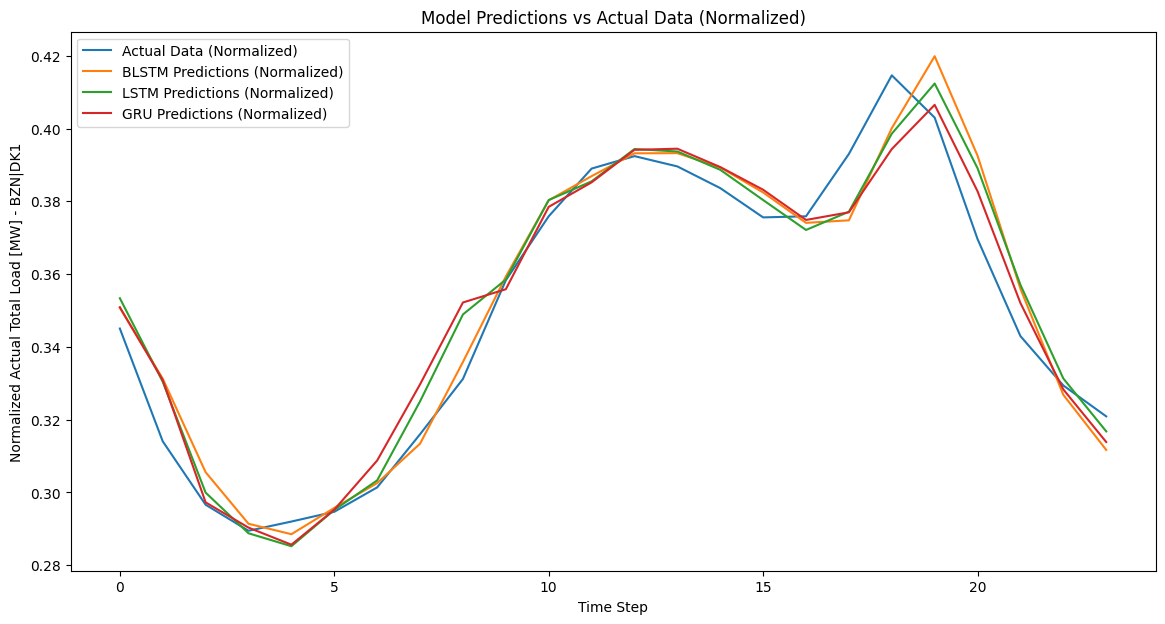

Denormalized predictions saved to CSV file.


'/kaggle/working/load_predictions_1.csv'

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, GRU, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
# Assuming df_merged is already loaded with the data
df = df_merged

# Select the relevant column and drop missing values
column_name = "Actual Total Load [MW] - BZN|DK1"
data = df[column_name].dropna()

# Reshape the data to a 2D array (required for MinMaxScaler)
data = data.values.reshape(-1, 1)

# Define train and test sizes
test_size = 97  # Adjust this value
train_size = len(data) - test_size

# Split the data into training and test sets
train_data = data[:train_size]
test_data = data[train_size:]

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
train_data_scaled = scaler.fit_transform(train_data)
test_data_scaled = scaler.transform(test_data)

# Function to create datasets for models
def create_dataset(dataset, time_step=1):
    X, Y = [], []
    for i in range(len(dataset) - time_step - 1):
        X.append(dataset[i:(i + time_step), 0])
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

# Set time step
time_step = 72
X_train, Y_train = create_dataset(train_data_scaled, time_step)
X_test, Y_test = create_dataset(test_data_scaled, time_step)

# Reshape input for models
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Function to create and train a model
def build_and_train_model(model_type):
    model = Sequential()
    if model_type == 'BLSTM':
        model.add(Bidirectional(LSTM(100, return_sequences=True, input_shape=(time_step, 1))))
        model.add(Bidirectional(LSTM(70)))
    elif model_type == 'LSTM':
        model.add(LSTM(100, return_sequences=True, input_shape=(time_step, 1)))
        model.add(LSTM(70))
    elif model_type == 'GRU':
        model.add(GRU(100, return_sequences=True, input_shape=(time_step, 1)))
        model.add(GRU(70))
    model.add(Dropout(0.2))
    # Use sigmoid activation to ensure output between 0 and 1
    model.add(Dense(1, activation='sigmoid'))  
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
    
    # Train the model
    model.fit(X_train, Y_train, validation_data=(X_test, Y_test), epochs=5, batch_size=32, verbose=1)
    
    return model

# Build and train the models
blstm_model = build_and_train_model('BLSTM')
lstm_model = build_and_train_model('LSTM')
gru_model = build_and_train_model('GRU')

# Make predictions
blstm_predict = blstm_model.predict(X_test)
lstm_predict = lstm_model.predict(X_test)
gru_predict = gru_model.predict(X_test)

# Calculate normalized MAE and RMSE for each model
blstm_mae = mean_absolute_error(Y_test, blstm_predict)
blstm_rmse = mean_squared_error(Y_test, blstm_predict, squared=False)

lstm_mae = mean_absolute_error(Y_test, lstm_predict)
lstm_rmse = mean_squared_error(Y_test, lstm_predict, squared=False)

gru_mae = mean_absolute_error(Y_test, gru_predict)
gru_rmse = mean_squared_error(Y_test, gru_predict, squared=False)

print("BLSTM MAE (Normalized):", blstm_mae)
print("BLSTM RMSE (Normalized):", blstm_rmse)
print("LSTM MAE (Normalized):", lstm_mae)
print("LSTM RMSE (Normalized):", lstm_rmse)
print("GRU MAE (Normalized):", gru_mae)
print("GRU RMSE (Normalized):", gru_rmse)

# Plotting normalized predictions
plt.figure(figsize=(14, 7))
plt.plot(np.arange(len(Y_test)), Y_test, label='Actual Data (Normalized)')
plt.plot(np.arange(len(blstm_predict)), blstm_predict, label='BLSTM Predictions (Normalized)')
plt.plot(np.arange(len(lstm_predict)), lstm_predict, label='LSTM Predictions (Normalized)')
plt.plot(np.arange(len(gru_predict)), gru_predict, label='GRU Predictions (Normalized)')
plt.xlabel('Time Step')
plt.ylabel('Normalized ' + column_name)
plt.title('Model Predictions vs Actual Data (Normalized)')
plt.legend()
plt.show()

# Denormalize predictions
blstm_predict_denorm = scaler.inverse_transform(blstm_predict)
lstm_predict_denorm = scaler.inverse_transform(lstm_predict)
gru_predict_denorm = scaler.inverse_transform(gru_predict)
Y_test_denorm = scaler.inverse_transform(Y_test.reshape(-1, 1))

# Store denormalized predictions in a DataFrame
predictions_df = pd.DataFrame({
    'Actual': Y_test_denorm.flatten(),
    'BLSTM_Predicted': blstm_predict_denorm.flatten(),
    'LSTM_Predicted': lstm_predict_denorm.flatten(),
    'GRU_Predicted': gru_predict_denorm.flatten()
})

# Save the DataFrame to a CSV file
file_path = '/kaggle/working/load_predictions_1.csv'
predictions_df.to_csv(file_path, index=False)

print("Denormalized predictions saved to CSV file.")

# Display link for download
file_path


# Price Forecast

In [75]:
import pandas as pd

# Load the CSV files
file_2015='/kaggle/input/forecast-data-denmark-city/Price_2015.csv'
file_2016='/kaggle/input/forecast-data-denmark-city/Price_2016.csv'
file_2017='/kaggle/input/forecast-data-denmark-city/Price_2017.csv'
file_2018='/kaggle/input/forecast-data-denmark-city/Price_2018.csv'
file_2019 ='/kaggle/input/forecast-data-denmark-city/Price_2019.csv'
file_2020 = '/kaggle/input/forecast-data-denmark-city/price_2020.csv'
file_2021 = '/kaggle/input/forecast-data-denmark-city/price_2021.csv'

df_2015 = pd.read_csv(file_2015)
df_2016 = pd.read_csv(file_2016)
df_2017 = pd.read_csv(file_2017)
df_2018 = pd.read_csv(file_2018)
df_2019 = pd.read_csv(file_2019)
df_2020 = pd.read_csv(file_2020)
df_2021 = pd.read_csv(file_2021)

# Merge the DataFrames into a single DataFrzame
df_merged = pd.concat([df_2015,df_2016,df_2017,df_2018,df_2019,df_2020,df_2021])

# Extract the first date-time part from the 'MTU (CET/CEST)' column
df_merged['MTU (CET/CEST)'] = df_merged['MTU (CET/CEST)'].str.split(' ').str[0]

# Convert to datetime with flexible parsing
df_merged['MTU (CET/CEST)'] = pd.to_datetime(df_merged['MTU (CET/CEST)'], dayfirst=True, errors='coerce')

# Sort the DataFrame by the datetime column
# df_merged.sort_values(by='MTU (CET/CEST)', inplace=True)

# Reset the index to maintain a default integer index
df_merged.reset_index(drop=True, inplace=True)

# Display the first few rows of the merged DataFrame
df_merged.head()


,MTU (CET/CEST),Day-ahead Price [EUR/MWh],Currency,BZN|DK1
0,2015-01-01,25.02,EUR,NaN
1,2015-01-01,18.29,EUR,NaN
2,2015-01-01,16.04,EUR,NaN
3,2015-01-01,14.60,EUR,NaN
4,2015-01-01,14.95,EUR,NaN


Epoch 1/5


/opt/conda/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1913/1913 ━━━━━━━━━━━━━━━━━━━━ 43s 20ms/step - loss: 0.0040 - val_loss: 6.0763e-04
Epoch 2/5
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - loss: 2.8770e-04 - val_loss: 6.6823e-04
Epoch 3/5
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - loss: 2.2175e-04 - val_loss: 5.7438e-04
Epoch 4/5
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - loss: 2.0744e-04 - val_loss: 5.5878e-04
Epoch 5/5
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - loss: 1.8705e-04 - val_loss: 5.2535e-04
Epoch 1/5
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 0.0043 - val_loss: 0.0015
Epoch 2/5
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 4.8051e-04 - val_loss: 7.8622e-04
Epoch 3/5
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 2.9088e-04 - val_loss: 6.0166e-04
Epoch 4/5
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 2.4200e-04 - val_loss: 5.3917e-04
Epoch 5/5
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 2.0742e-04 - val_loss: 5.3697e-04
Epoch 1/5
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/st

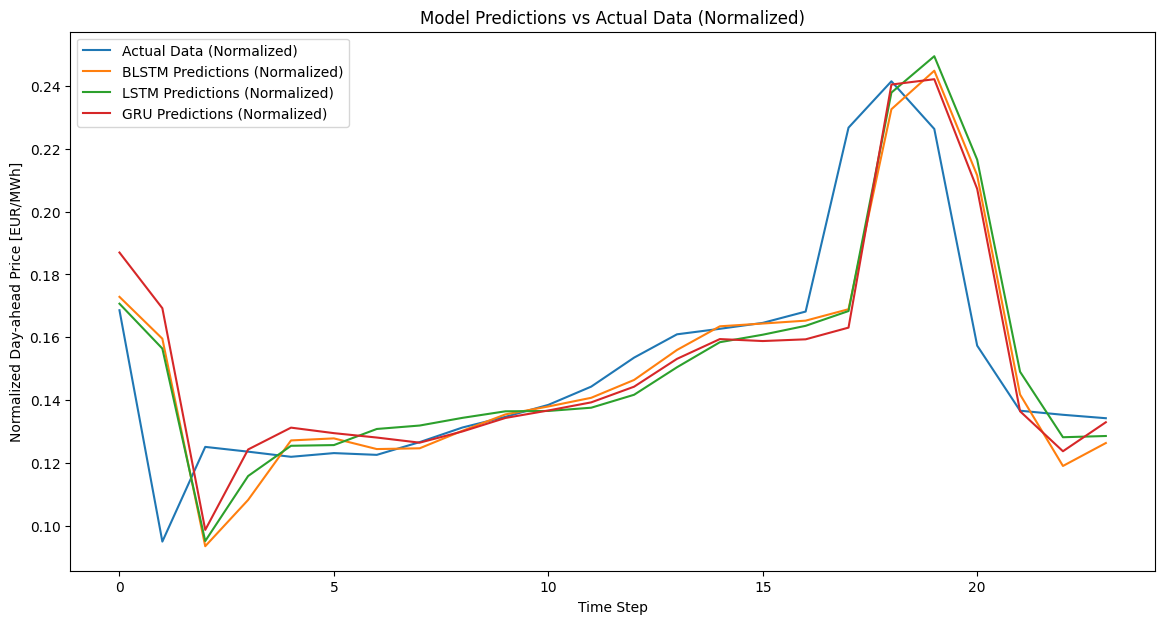

Denormalized predictions saved to CSV file.


'/kaggle/working/denormalized_predictions_price_3.csv'

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, GRU, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Assuming df_merged is already loaded with the data
df = df_merged

# Select the relevant column and drop missing values
column_name = "Day-ahead Price [EUR/MWh]"
data = df[column_name].dropna()

# Reshape the data to a 2D array (required for MinMaxScaler)
data = data.values.reshape(-1, 1)

# Define train and test sizes
test_size = 97  # Adjust this value
train_size = len(data) - test_size

# Split the data into training and test sets
train_data = data[:train_size]
test_data = data[train_size:]

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
train_data_scaled = scaler.fit_transform(train_data)
test_data_scaled = scaler.transform(test_data)

# Function to create datasets for models
def create_dataset(dataset, time_step=1):
    X, Y = [], []
    for i in range(len(dataset) - time_step - 1):
        X.append(dataset[i:(i + time_step), 0])
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

# Set time step
time_step = 72
X_train, Y_train = create_dataset(train_data_scaled, time_step)
X_test, Y_test = create_dataset(test_data_scaled, time_step)

# Reshape input for models
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Function to create and train a model
def build_and_train_model(model_type):
    model = Sequential()
    if model_type == 'BLSTM':
        model.add(Bidirectional(LSTM(100, return_sequences=True, input_shape=(time_step, 1))))
        model.add(Bidirectional(LSTM(85)))
    elif model_type == 'LSTM':
        model.add(LSTM(100, return_sequences=True, input_shape=(time_step, 1)))
        model.add(LSTM(85))
    elif model_type == 'GRU':
        model.add(GRU(100, return_sequences=True, input_shape=(time_step, 1)))
        model.add(GRU(85))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))  # Sigmoid activation for output between 0 and 1
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
    
    # Train the model
    model.fit(X_train, Y_train, validation_data=(X_test, Y_test), epochs=5, batch_size=32, verbose=1)
    
    return model
tf. random. set_seed(4)
# Build and train the models
blstm_model = build_and_train_model('BLSTM')
lstm_model = build_and_train_model('LSTM')
gru_model = build_and_train_model('GRU')

# Make predictions
blstm_predict = blstm_model.predict(X_test)
lstm_predict = lstm_model.predict(X_test)
gru_predict = gru_model.predict(X_test)

# Calculate normalized MAE and RMSE for each model
blstm_mae = mean_absolute_error(Y_test, blstm_predict)
blstm_rmse = mean_squared_error(Y_test, blstm_predict, squared=False)

lstm_mae = mean_absolute_error(Y_test, lstm_predict)
lstm_rmse = mean_squared_error(Y_test, lstm_predict, squared=False)

gru_mae = mean_absolute_error(Y_test, gru_predict)
gru_rmse = mean_squared_error(Y_test, gru_predict, squared=False)

# Print evaluation metrics
print(f"BLSTM MAE (Normalized): {blstm_mae}, RMSE (Normalized): {blstm_rmse}")
print(f"LSTM MAE (Normalized): {lstm_mae}, RMSE (Normalized): {lstm_rmse}")
print(f"GRU MAE (Normalized): {gru_mae}, RMSE (Normalized): {gru_rmse}")

# Plotting normalized predictions
plt.figure(figsize=(14, 7))
plt.plot(np.arange(len(Y_test)), Y_test, label='Actual Data (Normalized)')
plt.plot(np.arange(len(blstm_predict)), blstm_predict, label='BLSTM Predictions (Normalized)')
plt.plot(np.arange(len(lstm_predict)), lstm_predict, label='LSTM Predictions (Normalized)')
plt.plot(np.arange(len(gru_predict)), gru_predict, label='GRU Predictions (Normalized)')
plt.xlabel('Time Step')
plt.ylabel('Normalized ' + column_name)
plt.title('Model Predictions vs Actual Data (Normalized)')
plt.legend()
plt.show()

# Denormalize predictions
blstm_predict_denorm = scaler.inverse_transform(blstm_predict)
lstm_predict_denorm = scaler.inverse_transform(lstm_predict)
gru_predict_denorm = scaler.inverse_transform(gru_predict)
Y_test_denorm = scaler.inverse_transform(Y_test.reshape(-1, 1))

# Store denormalized predictions in a DataFrame
predictions_df = pd.DataFrame({
    'Actual': Y_test_denorm.flatten(),
    'BLSTM_Predicted': blstm_predict_denorm.flatten(),
    'LSTM_Predicted': lstm_predict_denorm.flatten(),
    'GRU_Predicted': gru_predict_denorm.flatten()
})

# Save the DataFrame to a CSV file
file_path = '/kaggle/working/denormalized_predictions_price_3.csv'
predictions_df.to_csv(file_path, index=False)

print("Denormalized predictions saved to CSV file.")

# Display link for download
file_path


In [30]:
import pandas as pd

# Load the CSV files
file_2015='/kaggle/input/forecast-data-denmark-city/solar_wind_2015.csv'
file_2016='/kaggle/input/forecast-data-denmark-city/solar_wind_2016.csv'
file_2017='/kaggle/input/forecast-data-denmark-city/solar_wind_2017.csv'
file_2018='/kaggle/input/forecast-data-denmark-city/solar_wind_2018.csv'
file_2019 ='/kaggle/input/forecast-data-denmark-city/Wind_solar_2019.csv'
file_2020 = '/kaggle/input/forecast-data-denmark-city/solar_wind_2020.csv'
file_2021 = '/kaggle/input/forecast-data-denmark-city/solar_wind_2021.csv'

df_2015 = pd.read_csv(file_2015)
df_2016 = pd.read_csv(file_2016)
df_2017 = pd.read_csv(file_2017)
df_2018 = pd.read_csv(file_2018)
df_2019 = pd.read_csv(file_2019)
df_2020 = pd.read_csv(file_2020)
df_2021 = pd.read_csv(file_2021)

# Merge the DataFrames into a single DataFrzame
df_merged = pd.concat([df_2016,df_2017,df_2018,df_2019,df_2020,df_2021])

# Extract the first date-time part from the 'MTU (CET/CEST)' column
df_merged['MTU (CET/CEST)'] = df_merged['MTU (CET/CEST)'].str.split(' ').str[0]

# Convert to datetime with flexible parsing
df_merged['MTU (CET/CEST)'] = pd.to_datetime(df_merged['MTU (CET/CEST)'], dayfirst=True, errors='coerce')

# Sort the DataFrame by the datetime column
# df_merged.sort_values(by='MTU (CET/CEST)', inplace=True)

# Reset the index to maintain a default integer index
df_merged.reset_index(drop=True, inplace=True)

# Display the first few rows of the merged DataFrame
df_merged.head()


,MTU (CET/CEST),Generation - Solar [MW] Day Ahead/ BZN|DK1,Generation - Solar [MW] Intraday / BZN|DK1,Generation - Solar [MW] Current / BZN|DK1,Generation - Wind Offshore [MW] Day Ahead/ BZN|DK1,Generation - Wind Offshore [MW] Intraday / BZN|DK1,Generation - Wind Offshore [MW] Current / BZN|DK1,Generation - Wind Onshore [MW] Day Ahead/ BZN|DK1,Generation - Wind Onshore [MW] Intraday / BZN|DK1,Generation - Wind Onshore [MW] Current / BZN|DK1
0,2016-01-01,0.0,n/e,n/e,399.0,n/e,n/e,519.0,n/e,n/e
1,2016-01-01,0.0,n/e,n/e,408.0,n/e,n/e,538.0,n/e,n/e
2,2016-01-01,0.0,n/e,n/e,413.0,n/e,n/e,530.0,n/e,n/e
3,2016-01-01,0.0,n/e,n/e,407.0,n/e,n/e,523.0,n/e,n/e
4,2016-01-01,0.0,n/e,n/e,352.0,n/e,n/e,512.0,n/e,n/e


# solar

Epoch 1/10


/opt/conda/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1635/1635 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - loss: 0.0133 - val_loss: 9.4911e-05
Epoch 2/10
1635/1635 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - loss: 6.3457e-04 - val_loss: 2.6640e-05
Epoch 3/10
1635/1635 ━━━━━━━━━━━━━━━━━━━━ 32s 19ms/step - loss: 4.5392e-04 - val_loss: 1.4243e-05
Epoch 4/10
1635/1635 ━━━━━━━━━━━━━━━━━━━━ 31s 19ms/step - loss: 3.9137e-04 - val_loss: 5.1406e-05
Epoch 5/10
1635/1635 ━━━━━━━━━━━━━━━━━━━━ 31s 19ms/step - loss: 3.3777e-04 - val_loss: 1.9090e-05
Epoch 6/10
1635/1635 ━━━━━━━━━━━━━━━━━━━━ 31s 19ms/step - loss: 3.2823e-04 - val_loss: 6.2737e-06
Epoch 7/10
1635/1635 ━━━━━━━━━━━━━━━━━━━━ 31s 19ms/step - loss: 3.1440e-04 - val_loss: 3.9731e-05
Epoch 8/10
1635/1635 ━━━━━━━━━━━━━━━━━━━━ 31s 19ms/step - loss: 2.8077e-04 - val_loss: 1.5675e-05
Epoch 9/10
1635/1635 ━━━━━━━━━━━━━━━━━━━━ 32s 19ms/step - loss: 2.7892e-04 - val_loss: 4.1362e-05
Epoch 10/10
1635/1635 ━━━━━━━━━━━━━━━━━━━━ 31s 19ms/step - loss: 2.9683e-04 - val_loss: 7.1442e-06
Epoch 1/10
1635/1635 ━━━━━━━━━━━━━

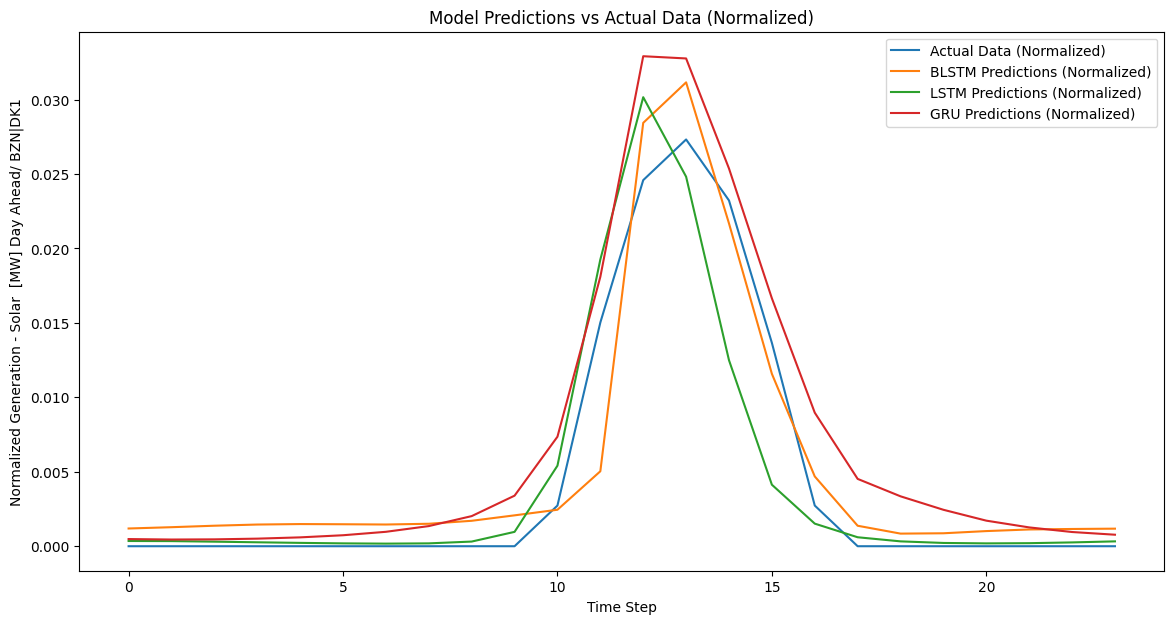

BLSTM MAE (Normalized): 0.0019218021237369005, RMSE (Normalized): 0.0026728690259733403
LSTM MAE (Normalized): 0.0017461590974721605, RMSE (Normalized): 0.003367407559793968
GRU MAE (Normalized): 0.0024515119582921535, RMSE (Normalized): 0.0032021191444877263
Denormalized predictions and errors saved to CSV file.


'/kaggle/working/denormalized_predictions_solar_2.csv'

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, GRU, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Assuming df_merged is already loaded with the data
df = df_merged

# Select the relevant column and drop missing values
column_name = "Generation - Solar  [MW] Day Ahead/ BZN|DK1"
data = df[column_name].dropna()

# Reshape the data to a 2D array (required for MinMaxScaler)
data = data.values.reshape(-1, 1)

# Define train and test sizes
test_size = 97  # Adjust this value
train_size = len(data) - test_size

# Split the data into training and test sets
train_data = data[:train_size]
test_data = data[train_size:]

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
train_data_scaled = scaler.fit_transform(train_data)
test_data_scaled = scaler.transform(test_data)

# Function to create datasets for models
def create_dataset(dataset, time_step=1):
    X, Y = [], []
    for i in range(len(dataset) - time_step - 1):
        X.append(dataset[i:(i + time_step), 0])
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

# Set time step
time_step = 72
X_train, Y_train = create_dataset(train_data_scaled, time_step)
X_test, Y_test = create_dataset(test_data_scaled, time_step)

# Reshape input for models
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Function to create and train a model
def build_and_train_model(model_type):
    model = Sequential()
    if model_type == 'BLSTM':
        model.add(Bidirectional(LSTM(100, return_sequences=True, input_shape=(time_step, 1))))
        model.add(Bidirectional(LSTM(50)))
    elif model_type == 'LSTM':
        model.add(LSTM(100, return_sequences=True, input_shape=(time_step, 1)))
        model.add(LSTM(50))
    elif model_type == 'GRU':
        model.add(GRU(100, return_sequences=True, input_shape=(time_step, 1)))
        model.add(GRU(50))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))  # Sigmoid activation for output between 0 and 1
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
    
    # Train the model
    model.fit(X_train, Y_train, validation_data=(X_test, Y_test), epochs=10, batch_size=32, verbose=1)
    
    return model

# Build and train the models
blstm_model = build_and_train_model('BLSTM')
lstm_model = build_and_train_model('LSTM')
gru_model = build_and_train_model('GRU')

# Make predictions
blstm_predict = blstm_model.predict(X_test)
lstm_predict = lstm_model.predict(X_test)
gru_predict = gru_model.predict(X_test)

# Plotting normalized predictions
plt.figure(figsize=(14, 7))
plt.plot(np.arange(len(Y_test)), Y_test, label='Actual Data (Normalized)')
plt.plot(np.arange(len(blstm_predict)), blstm_predict, label='BLSTM Predictions (Normalized)')
plt.plot(np.arange(len(lstm_predict)), lstm_predict, label='LSTM Predictions (Normalized)')
plt.plot(np.arange(len(gru_predict)), gru_predict, label='GRU Predictions (Normalized)')
plt.xlabel('Time Step')
plt.ylabel('Normalized ' + column_name)
plt.title('Model Predictions vs Actual Data (Normalized)')
plt.legend()
plt.show()

# Calculate normalized MAE and RMSE for each model
blstm_mae = mean_absolute_error(Y_test, blstm_predict)
blstm_rmse = np.sqrt(mean_squared_error(Y_test, blstm_predict))

lstm_mae = mean_absolute_error(Y_test, lstm_predict)
lstm_rmse = np.sqrt(mean_squared_error(Y_test, lstm_predict))

gru_mae = mean_absolute_error(Y_test, gru_predict)
gru_rmse = np.sqrt(mean_squared_error(Y_test, gru_predict))

# Print evaluation metrics
print(f"BLSTM MAE (Normalized): {blstm_mae}, RMSE (Normalized): {blstm_rmse}")
print(f"LSTM MAE (Normalized): {lstm_mae}, RMSE (Normalized): {lstm_rmse}")
print(f"GRU MAE (Normalized): {gru_mae}, RMSE (Normalized): {gru_rmse}")

# Denormalize predictions
blstm_predict_denorm = scaler.inverse_transform(blstm_predict)
lstm_predict_denorm = scaler.inverse_transform(lstm_predict)
gru_predict_denorm = scaler.inverse_transform(gru_predict)
Y_test_denorm = scaler.inverse_transform(Y_test.reshape(-1, 1))

# Store denormalized predictions and errors in a DataFrame
predictions_df = pd.DataFrame({
    'Actual': Y_test_denorm.flatten(),
    'BLSTM_Predicted': blstm_predict_denorm.flatten(),
    'LSTM_Predicted': lstm_predict_denorm.flatten(),
    'GRU_Predicted': gru_predict_denorm.flatten(),
    'BLSTM_MAE (Normalized)': [blstm_mae] * len(Y_test),
    'BLSTM_RMSE (Normalized)': [blstm_rmse] * len(Y_test),
    'LSTM_MAE (Normalized)': [lstm_mae] * len(Y_test),
    'LSTM_RMSE (Normalized)': [lstm_rmse] * len(Y_test),
    'GRU_MAE (Normalized)': [gru_mae] * len(Y_test),
    'GRU_RMSE (Normalized)': [gru_rmse] * len(Y_test)
})

# Save the DataFrame to a CSV file
file_path = '/kaggle/working/denormalized_predictions_solar_2.csv'
predictions_df.to_csv(file_path, index=False)

print("Denormalized predictions and errors saved to CSV file.")

# Display link for download
file_path


# Wind

Epoch 1/10


/opt/conda/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1633/1633 ━━━━━━━━━━━━━━━━━━━━ 35s 20ms/step - loss: 0.0092 - val_loss: 4.8909e-04
Epoch 2/10
1633/1633 ━━━━━━━━━━━━━━━━━━━━ 31s 19ms/step - loss: 0.0011 - val_loss: 4.2952e-04
Epoch 3/10
1633/1633 ━━━━━━━━━━━━━━━━━━━━ 31s 19ms/step - loss: 9.0591e-04 - val_loss: 3.3855e-04
Epoch 4/10
1633/1633 ━━━━━━━━━━━━━━━━━━━━ 31s 19ms/step - loss: 8.0118e-04 - val_loss: 3.7985e-04
Epoch 5/10
1633/1633 ━━━━━━━━━━━━━━━━━━━━ 31s 19ms/step - loss: 8.0091e-04 - val_loss: 3.8920e-04
Epoch 6/10
1633/1633 ━━━━━━━━━━━━━━━━━━━━ 32s 19ms/step - loss: 7.3895e-04 - val_loss: 4.1937e-04
Epoch 7/10
1633/1633 ━━━━━━━━━━━━━━━━━━━━ 31s 19ms/step - loss: 6.8996e-04 - val_loss: 4.0872e-04
Epoch 8/10
1633/1633 ━━━━━━━━━━━━━━━━━━━━ 31s 19ms/step - loss: 7.2667e-04 - val_loss: 5.0749e-04
Epoch 9/10
1633/1633 ━━━━━━━━━━━━━━━━━━━━ 31s 19ms/step - loss: 6.7641e-04 - val_loss: 3.3624e-04
Epoch 10/10
1633/1633 ━━━━━━━━━━━━━━━━━━━━ 31s 19ms/step - loss: 6.5033e-04 - val_loss: 3.2516e-04
Epoch 1/10
1633/1633 ━━━━━━━━━━━━━━━━━

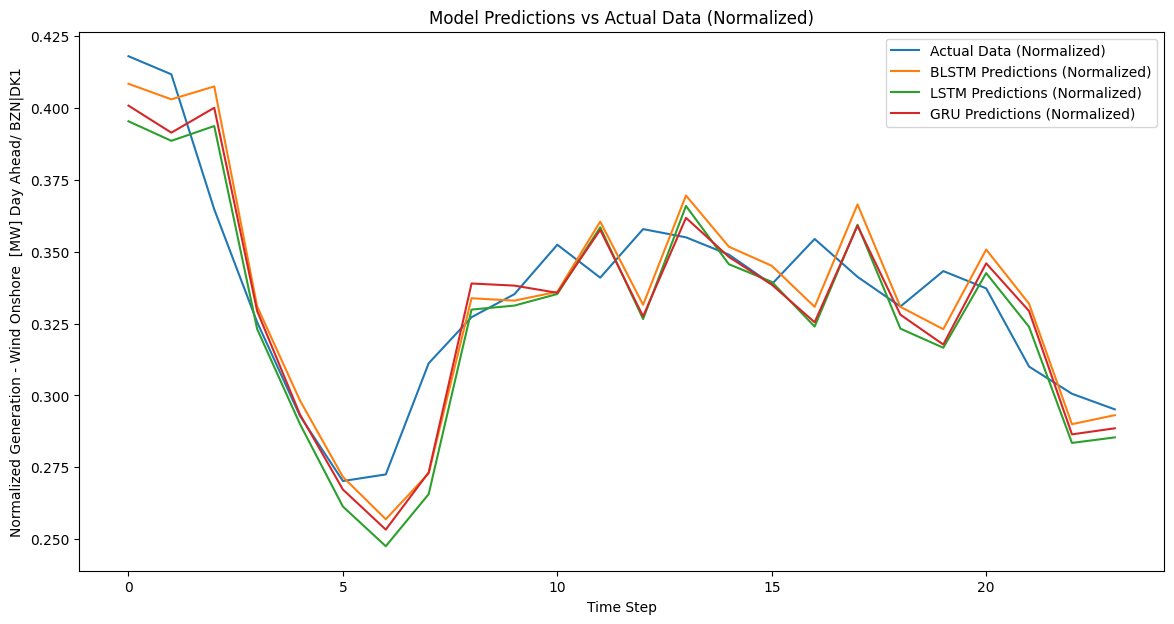

BLSTM MAE (Normalized): 0.014137690757697496, RMSE (Normalized): 0.01803218907226423
LSTM MAE (Normalized): 0.015671969339991595, RMSE (Normalized): 0.019419742617154345
GRU MAE (Normalized): 0.014476860518128729, RMSE (Normalized): 0.018228388349426475
Denormalized predictions and errors saved to CSV file.


'/kaggle/working/denormalized_predictions_solar_1.csv'

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, GRU, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Assuming df_merged is already loaded with the data
df = df_merged

# Select the relevant column and drop missing values
column_name = "Generation - Wind Onshore  [MW] Day Ahead/ BZN|DK1"
data = df[column_name].dropna()

# Reshape the data to a 2D array (required for MinMaxScaler)
data = data.values.reshape(-1, 1)

# Define train and test sizes
test_size = 97  # Adjust this value
train_size = len(data) - test_size

# Split the data into training and test sets
train_data = data[:train_size]
test_data = data[train_size:]

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
train_data_scaled = scaler.fit_transform(train_data)
test_data_scaled = scaler.transform(test_data)

# Function to create datasets for models
def create_dataset(dataset, time_step=1):
    X, Y = [], []
    for i in range(len(dataset) - time_step - 1):
        X.append(dataset[i:(i + time_step), 0])
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

# Set time step
time_step = 72
X_train, Y_train = create_dataset(train_data_scaled, time_step)
X_test, Y_test = create_dataset(test_data_scaled, time_step)

# Reshape input for models
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Function to create and train a model
def build_and_train_model(model_type):
    model = Sequential()
    if model_type == 'BLSTM':
        model.add(Bidirectional(LSTM(100, return_sequences=True, input_shape=(time_step, 1))))
        model.add(Bidirectional(LSTM(50)))
    elif model_type == 'LSTM':
        model.add(LSTM(100, return_sequences=True, input_shape=(time_step, 1)))
        model.add(LSTM(50))
    elif model_type == 'GRU':
        model.add(GRU(100, return_sequences=True, input_shape=(time_step, 1)))
        model.add(GRU(50))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))  # Sigmoid activation for output between 0 and 1
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
    
    # Train the model
    model.fit(X_train, Y_train, validation_data=(X_test, Y_test), epochs=10, batch_size=32, verbose=1)
    
    return model

# Build and train the models
blstm_model = build_and_train_model('BLSTM')
lstm_model = build_and_train_model('LSTM')
gru_model = build_and_train_model('GRU')

# Make predictions
blstm_predict = blstm_model.predict(X_test)
lstm_predict = lstm_model.predict(X_test)
gru_predict = gru_model.predict(X_test)

# Plotting normalized predictions
plt.figure(figsize=(14, 7))
plt.plot(np.arange(len(Y_test)), Y_test, label='Actual Data (Normalized)')
plt.plot(np.arange(len(blstm_predict)), blstm_predict, label='BLSTM Predictions (Normalized)')
plt.plot(np.arange(len(lstm_predict)), lstm_predict, label='LSTM Predictions (Normalized)')
plt.plot(np.arange(len(gru_predict)), gru_predict, label='GRU Predictions (Normalized)')
plt.xlabel('Time Step')
plt.ylabel('Normalized ' + column_name)
plt.title('Model Predictions vs Actual Data (Normalized)')
plt.legend()
plt.show()

# Calculate normalized MAE and RMSE for each model
blstm_mae = mean_absolute_error(Y_test, blstm_predict)
blstm_rmse = np.sqrt(mean_squared_error(Y_test, blstm_predict))

lstm_mae = mean_absolute_error(Y_test, lstm_predict)
lstm_rmse = np.sqrt(mean_squared_error(Y_test, lstm_predict))

gru_mae = mean_absolute_error(Y_test, gru_predict)
gru_rmse = np.sqrt(mean_squared_error(Y_test, gru_predict))

# Print evaluation metrics
print(f"BLSTM MAE (Normalized): {blstm_mae}, RMSE (Normalized): {blstm_rmse}")
print(f"LSTM MAE (Normalized): {lstm_mae}, RMSE (Normalized): {lstm_rmse}")
print(f"GRU MAE (Normalized): {gru_mae}, RMSE (Normalized): {gru_rmse}")

# Denormalize predictions
blstm_predict_denorm = scaler.inverse_transform(blstm_predict)
lstm_predict_denorm = scaler.inverse_transform(lstm_predict)
gru_predict_denorm = scaler.inverse_transform(gru_predict)
Y_test_denorm = scaler.inverse_transform(Y_test.reshape(-1, 1))

# Store denormalized predictions and errors in a DataFrame
predictions_df = pd.DataFrame({
    'Actual': Y_test_denorm.flatten(),
    'BLSTM_Predicted': blstm_predict_denorm.flatten(),
    'LSTM_Predicted': lstm_predict_denorm.flatten(),
    'GRU_Predicted': gru_predict_denorm.flatten(),
    'BLSTM_MAE (Normalized)': [blstm_mae] * len(Y_test),
    'BLSTM_RMSE (Normalized)': [blstm_rmse] * len(Y_test),
    'LSTM_MAE (Normalized)': [lstm_mae] * len(Y_test),
    'LSTM_RMSE (Normalized)': [lstm_rmse] * len(Y_test),
    'GRU_MAE (Normalized)': [gru_mae] * len(Y_test),
    'GRU_RMSE (Normalized)': [gru_rmse] * len(Y_test)
})

# Save the DataFrame to a CSV file
file_path = '/kaggle/working/denormalized_predictions_wind_1.csv'
predictions_df.to_csv(file_path, index=False)

print("Denormalized predictions and errors saved to CSV file.")

# Display link for download
file_path
